<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
df = pd.read_csv('/Users/michalbando/Downloads/Różne/IT/Python/data/survey_data_newest.csv')

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


Basic statistics for ConvertedCompYearly:


count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

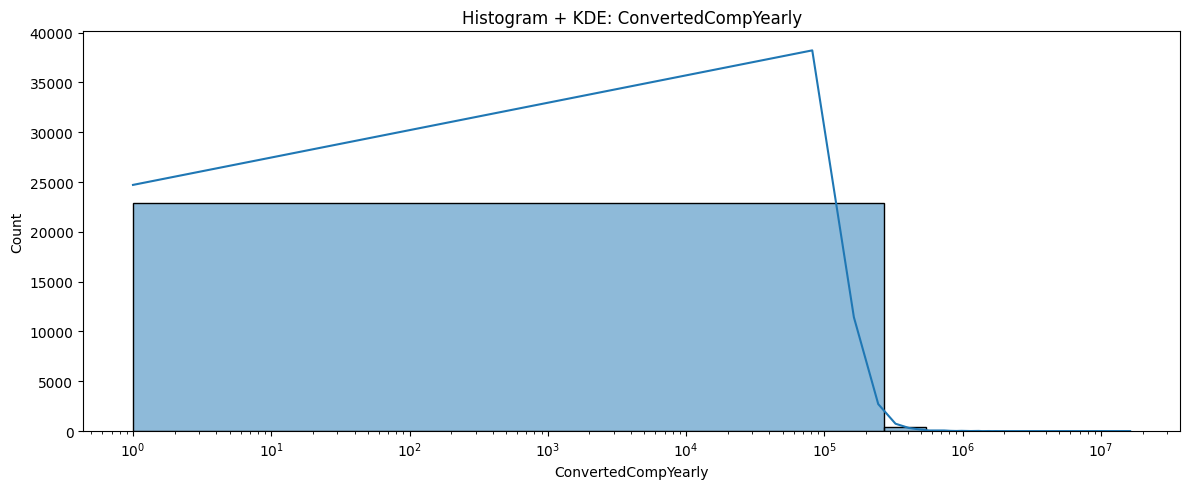

In [3]:
# Step 3: Analyze and visualize compensation distribution
# Upewniamy się, że kolumna jest liczbowa (nie-numeryczne -> NaN)
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')  # konwertuje wartości na float, błędy -> NaN

# Wyświetlamy podstawowe statystyki opisowe dla kolumny
print('Basic statistics for ConvertedCompYearly:')  # informacja tekstowa
display(df['ConvertedCompYearly'].describe())  # pokazuje count, mean, std, min, quartile, max

# Rysujemy histogram z KDE, aby zobaczyć rozkład
plt.figure(figsize=(12,5))  # ustawiamy rozmiar wykresu
sns.histplot(df['ConvertedCompYearly'].dropna(), bins=60, kde=True, stat='count')  # histogram z estymacją gęstości
plt.xlabel('ConvertedCompYearly')  # etykieta osi X
plt.ylabel('Count')  # etykieta osi Y
plt.title('Histogram + KDE: ConvertedCompYearly')  # tytuł wykresu

# Często rozkład kompensacji jest silnie skośny, więc pokazujemy też skalę logarytmiczną
plt.xscale('log')  # przełączamy oś X na skalę logarytmiczną, aby lepiej widzieć rozkład
plt.tight_layout()  # dopasowujemy elementy wykresu
plt.show()  # wyświetlamy wykres


<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
# Step 4: Median compensation for full-time employees
# Szukamy wierszy, gdzie Employment zawiera informację o pełnym etacie
mask_ft = df['Employment'].str.contains('Employed, full-time', na=False)  # True dla pełnoetatowych, NaN->False

# Pobieramy skorelowaną kolumnę i konwertujemy na liczbę (na wypadek tekstów)
comp_ft = pd.to_numeric(df.loc[mask_ft, 'ConvertedCompYearly'], errors='coerce')  # konwersja do float

# Obliczamy medianę dla pełnoetatowych
median_ft = comp_ft.median()  # mediana kompensacji
print(f"Median compensation (full-time): {median_ft:.2f}")  # wypisujemy wynik

# Dodatkowo pokażemy statystyki dla tej grupy
print('\nStatistics for full-time respondents:')
display(comp_ft.describe())  # opis statystyczny (count, mean, std, min, quartile, max)


Median compensation (full-time): 67666.00

Statistics for full-time respondents:


count    2.037400e+04
mean     8.741243e+04
std      1.598245e+05
min      1.000000e+00
25%      3.600000e+04
50%      6.766600e+04
75%      1.100000e+05
max      1.381802e+07
Name: ConvertedCompYearly, dtype: float64

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



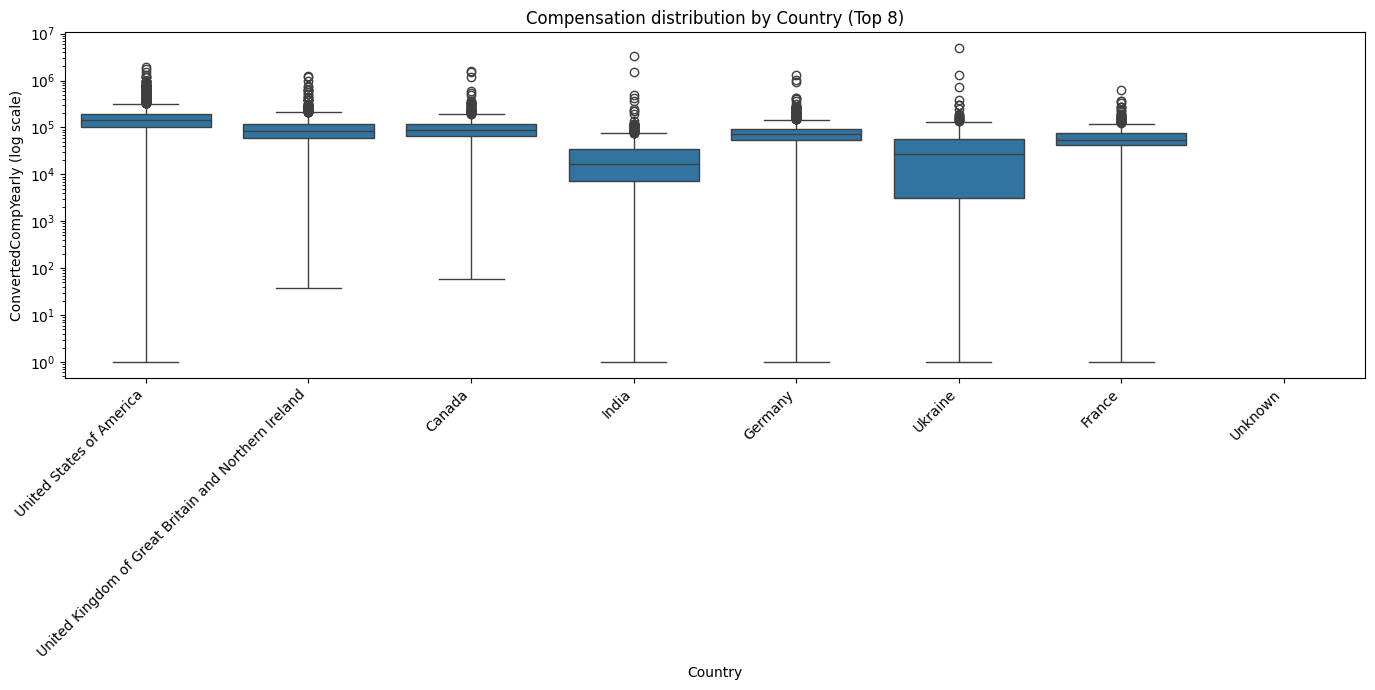

In [5]:
# Step 5: Compensation range and distribution by country (boxplots for top countries)
# Uzupełniamy brakujące wartości w kolumnie Country prostym 'Unknown'
df['Country'] = df['Country'].fillna('Unknown')  # brakujące kraje oznaczamy jako 'Unknown'

# Wybieramy top 8 krajów po liczbie respondentów, żeby wykres był czytelny
top_countries = df['Country'].value_counts().head(8).index.tolist()  # lista 8 najpopularniejszych krajów

# Rysujemy boxplot dla każdego z wybranych krajów
plt.figure(figsize=(14,7))  # rozmiar wykresu
sns.boxplot(data=df[df['Country'].isin(top_countries)], x='Country', y='ConvertedCompYearly')  # boxplot per country
plt.yscale('log')  # skala logarytmiczna osi Y aby zredukować wpływ ekstremów
plt.xlabel('Country')  # etykieta osi X
plt.ylabel('ConvertedCompYearly (log scale)')  # etykieta osi Y
plt.title('Compensation distribution by Country (Top 8)')  # tytuł wykresu
plt.xticks(rotation=45, ha='right')  # obracamy etykiety krajów dla czytelności
plt.tight_layout()  # dopasowanie wykresu
plt.show()  # wyświetlenie


<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [6]:
# Step 6: Remove outliers from ConvertedCompYearly using IQR method
# Tworzymy serię bez NaN, aby policzyć kwartyle
comp = df['ConvertedCompYearly'].dropna()  # usuwamy NaN do obliczeń kwartylowych
Q1 = comp.quantile(0.25)  # pierwszy kwartyl (25%)
Q3 = comp.quantile(0.75)  # trzeci kwartyl (75%)
IQR = Q3 - Q1  # rozstęp międzykwartylowy (IQR)

# Definiujemy granice na podstawie 1.5 * IQR (klasyczna reguła)
lower_bound = Q1 - 1.5 * IQR  # dolna granica
upper_bound = Q3 + 1.5 * IQR  # górna granica

# Tworzymy nowy DataFrame z pominiętymi wartościami spoza granic
df_clean = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)].copy()  # kopiujemy filtrowane wiersze

# Informujemy o efektach usunięcia outlierów
print(f"Original rows: {df.shape[0]}")  # liczba wierszy przed
print(f"Rows after removing IQR outliers: {df_clean.shape[0]}")  # liczba wierszy po
print(f"Removed {df.shape[0] - df_clean.shape[0]} rows ({(df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100:.2f}%) as outliers")  # ile usunięto

# Pokazujemy podstawowe statystyki po oczyszczeniu
print('\nStatistics after removing outliers:')
display(df_clean['ConvertedCompYearly'].describe())  # statystyki po usunięciu outlierów


Original rows: 65437
Rows after removing IQR outliers: 22457
Removed 42980 rows (65.68%) as outliers

Statistics after removing outliers:


count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


Columns used for correlation: ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']


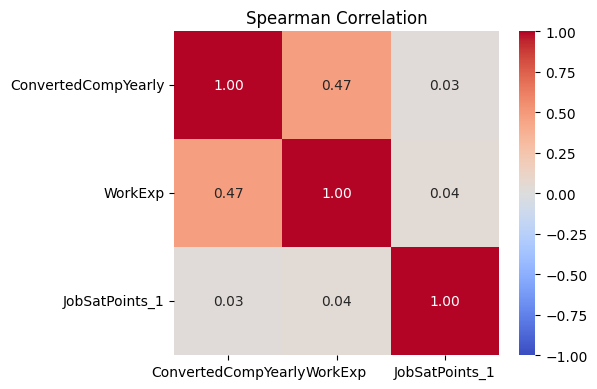

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.471187,0.025199
WorkExp,0.471187,1.000000,0.044651
JobSatPoints_1,0.025199,0.044651,1.000000


In [7]:
# Step 7: Finding correlations between ConvertedCompYearly, WorkExp, JobSatPoints_1
# Najpierw konwertujemy potencjalne kolumny do typu numerycznego (jeśli istnieją)
for col in ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')  # konwersja wartości na liczby, błędy->NaN

# Lista kolumn, które rzeczywiście występują w df_clean
cols_present = [c for c in ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1'] if c in df_clean.columns]
print('Columns used for correlation:', cols_present)  # pokazujemy, które kolumny weźmiemy pod uwagę

# Obliczamy macierz korelacji Spearmana (oparta na rangach, odporna na nieliniowości)
corr = df_clean[cols_present].corr(method='spearman')  # macierz korelacji Spearmana

# Rysujemy heatmapę korelacji
plt.figure(figsize=(6,4))  # rozmiar wykresu
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)  # heatmapa z anotacjami
plt.title('Spearman Correlation')  # tytuł
plt.tight_layout()  # dopasowanie
plt.show()  # wyświetlenie

# Wyświetlamy macierz korelacji jako tabela
display(corr)  # pokazujemy wartości korelacji


<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


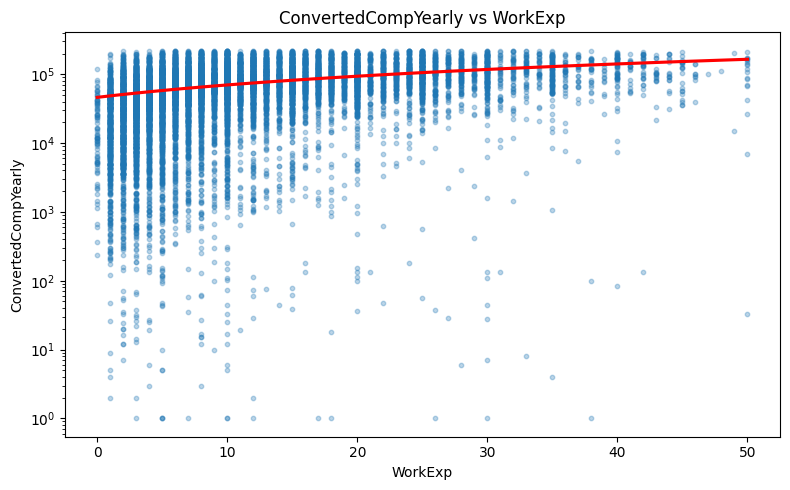

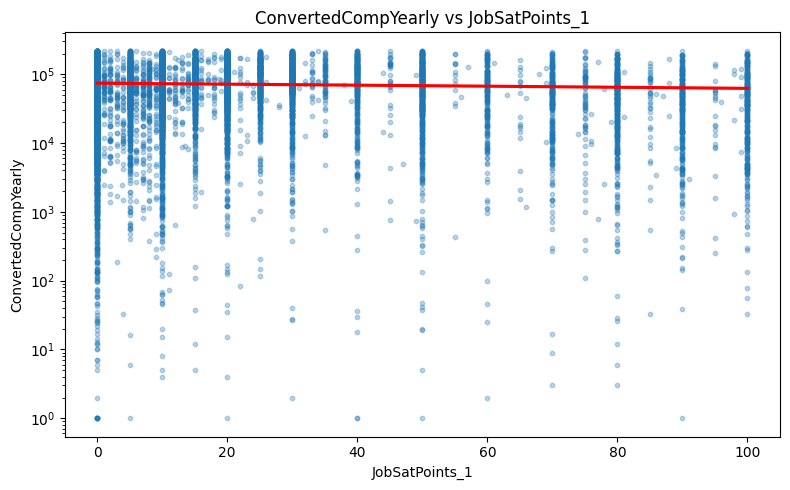

In [8]:
# Step 8: Scatter plots for correlations
# Rysujemy scatter + linię regresji dla ConvertedCompYearly vs WorkExp oraz vs JobSatPoints_1 (jeśli kolumny istnieją)

# Helper: funkcja rysująca regplot z obsługą braków i log-skali dla kompensacji
def plot_reg(xcol, ycol):
    """Rysuje regplot (z linią trendu) dla ycol vs xcol z komentarzami"""
    if xcol not in df_clean.columns or ycol not in df_clean.columns:
        print(f"Brakuje kolumny: {xcol} lub {ycol} - pomijam wykres")
        return
    plt.figure(figsize=(8,5))  # ustawiamy rozmiar wykresu
    sns.regplot(data=df_clean, x=xcol, y=ycol, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})  # scatter + linia regresji
    plt.yscale('log') if 'Comp' in ycol or 'ConvertedComp' in ycol else None  # log-scale dla kompensacji (jeśli występuje)
    plt.xscale('log') if 'Comp' in xcol or 'ConvertedComp' in xcol else None  # log-scale dla osi X jeśli potrzeba
    plt.title(f"{ycol} vs {xcol}")  # tytuł wykresu
    plt.tight_layout()  # dopasowanie elementów
    plt.show()  # wyświetlenie

# Rysujemy wykresy warunkowo
plot_reg('WorkExp', 'ConvertedCompYearly')  # relacja WorkExp -> Comp
plot_reg('JobSatPoints_1', 'ConvertedCompYearly')  # relacja JobSat -> Comp

# Alternatywnie możemy też wyświetlić scatter bez log-skali lub z próbkowaniem, jeśli dane są bardzo duże


<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
